In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import glob
import os
import re
from pathlib import Path

In [2]:
driver = "vGAT"
responder = "eOPN3"
illum_duration = 5 
time = str(illum_duration)+ "s"

genotypefilename = driver + " x " + responder  + "_" + time
drivercontrol_name = "w1118 x " + driver + "_" + time
respondercontrol_name = "w1118 x " + responder + "_" + time

homecomp = "C:\\Users\\User"
base_path = "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data compilation\\Trumelan\\2. Processed\\"  
specifiedpath = homecomp + base_path

# Analysis parameters
bin_size = 0.5  # seconds for heatmap resampling
framerate = 10  # Hz
illum_start = 60  # illumination start (seconds)
 # illumination duration (seconds)
maxtime = 3600
intendedtime = 3000

exp_path = specifiedpath + genotypefilename
drivercontrol_path = specifiedpath + drivercontrol_name
respondercontrol_path = specifiedpath + respondercontrol_name

#change here
fileofinterest = exp_path
fileofinterestname = genotypefilename

In [3]:
exp_combined_df = pd.read_csv(fileofinterest + "_max" + str(maxtime) + "s.csv").set_index('Time (s)')
intendedtimeexp = exp_combined_df.iloc[0:(intendedtime*2),:]

In [4]:
minutegraphs = intendedtimeexp.reset_index(drop=False)
time_cols = [col for col in minutegraphs.columns if "Time (s)" in col]
for col in time_cols:
    minutegraphs[col.replace("Time (s)", "Time(min)")] = minutegraphs[col] / 60
minutegraphs = minutegraphs.drop(columns=time_cols)
minutegraphs = minutegraphs.set_index("Time(min)") 

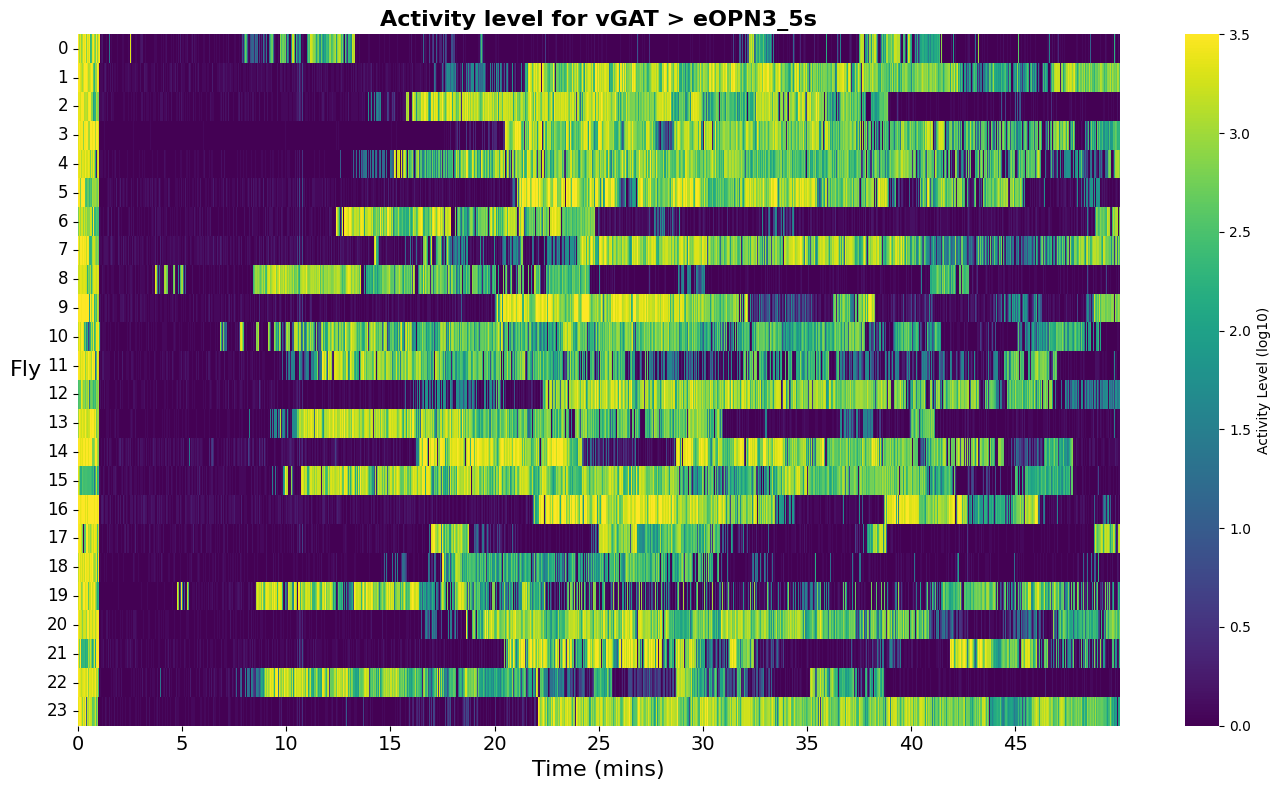

In [5]:
activityleveldf = minutegraphs.filter(regex="^ActivityLevel").T.reset_index(drop=True)

if responder == "eOPN3":
    responderrename = "AsOPN3"
if responder == "ACR":
    responderrename = "GtACR1"

fig, ax = plt.subplots(figsize=(14, 8))
hm = sns.heatmap(activityleveldf, cmap="viridis", cbar_kws={'label': 'Activity Level (log10)'}, xticklabels=12, yticklabels=True, vmin=0, vmax=3.5,  ax=ax)

# Get the QuadMesh and force it to rasterize
quadmesh = ax.collections[0]  # The heatmap is usually the first collection
quadmesh.set_rasterized(True)
quadmesh.set_edgecolor('face')  # Remove any edge colors
quadmesh.set_linewidth(0)

ax.tick_params(axis='y', labelsize=12)

tick_times = range(0, int(intendedtime/60), int(intendedtime/600))
tick_positions = [list(activityleveldf.columns).index(float(t)) for t in tick_times if float(t) in activityleveldf.columns]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_times, rotation=0, fontsize=14)
ax.tick_params(axis='y', rotation=0)

ax.set_xlabel("Time (mins)", fontsize=16)
ax.set_ylabel("Fly", rotation=0, labelpad=15, fontsize=16)
ax.set_title("Activity level for " + fileofinterestname.replace("x", ">") , weight="bold", fontsize=16)

fig.tight_layout()

import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'

fig.patch.set_facecolor('white')
ax.patch.set_facecolor('white')

# plt.savefig(homecomp + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data compilation\\Trumelan\\Trumelan images\\" 
#             + "Activitylevel_" + fileofinterestname + "_" +str(illum_duration) + "s.svg",
#             dpi=300, bbox_inches='tight', format='svg', facecolor='white', transparent=False)

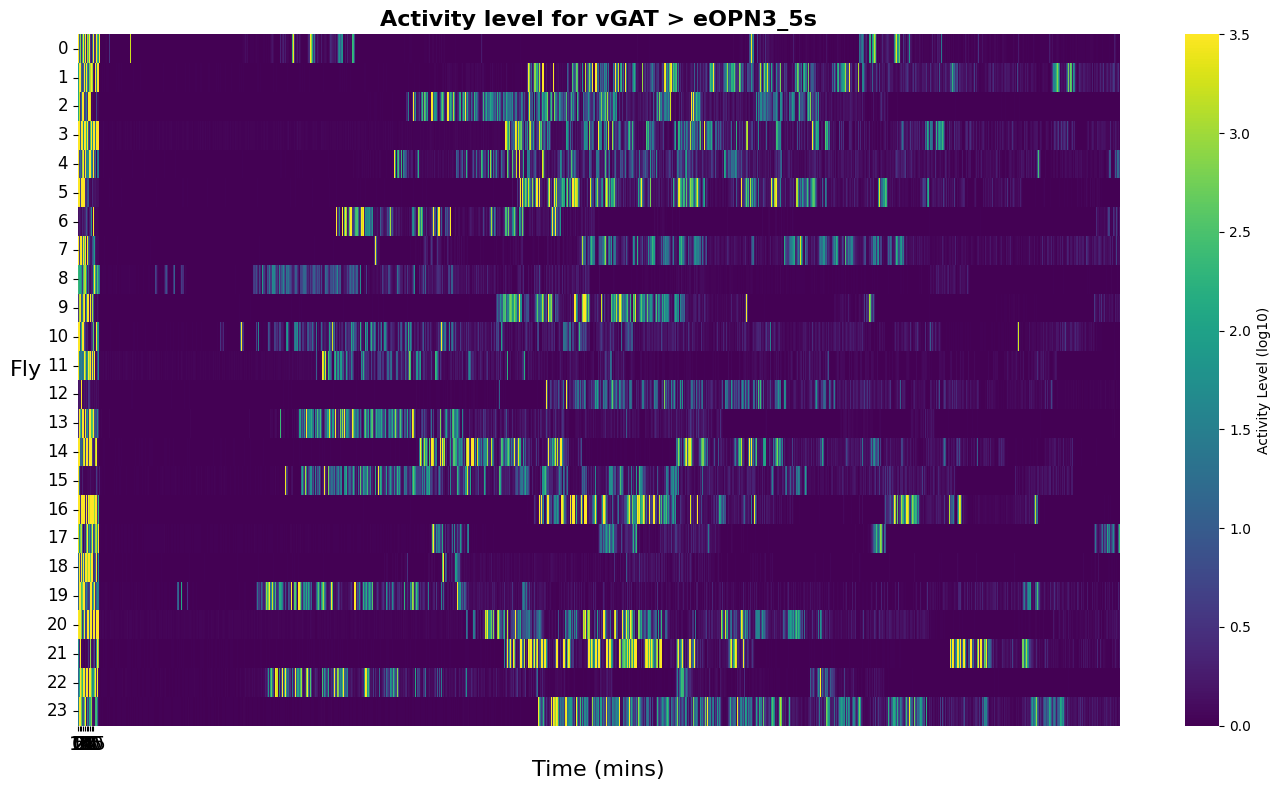

In [6]:
speeddf = intendedtimeexp.filter(regex="^Speed").T.reset_index(drop=True)

if responder == "eOPN3":
    responderrename = "AsOPN3"
if responder == "ACR":
    responderrename = "GtACR1"

fig, ax = plt.subplots(figsize=(14, 8))
hm = sns.heatmap(speeddf, cmap="viridis", cbar_kws={'label': 'Activity Level (log10)'}, xticklabels=12, yticklabels=True, vmin=0, vmax=3.5,  ax=ax)

# Get the QuadMesh and force it to rasterize
quadmesh = ax.collections[0]  # The heatmap is usually the first collection
quadmesh.set_rasterized(True)
quadmesh.set_edgecolor('face')  # Remove any edge colors
quadmesh.set_linewidth(0)

ax.tick_params(axis='y', labelsize=12)

tick_times = range(0, int(intendedtime/60), int(intendedtime/600))
tick_positions = [list(speeddf.columns).index(float(t)) for t in tick_times if float(t) in speeddf.columns]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_times, rotation=0, fontsize=14)
ax.tick_params(axis='y', rotation=0)

ax.set_xlabel("Time (mins)", fontsize=16)
ax.set_ylabel("Fly", rotation=0, labelpad=15, fontsize=16)
ax.set_title("Activity level for " + fileofinterestname.replace("x", ">") , weight="bold", fontsize=16)

fig.tight_layout()

import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'

fig.patch.set_facecolor('white')
ax.patch.set_facecolor('white')

# plt.savefig(homecomp + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data compilation\\Trumelan\\Trumelan images\\" 
#             + "Speedlevel_" + fileofinterestname + "_" +str(illum_duration) + "s.svg",
#             dpi=300, bbox_inches='tight', format='svg', facecolor='white', transparent=False)

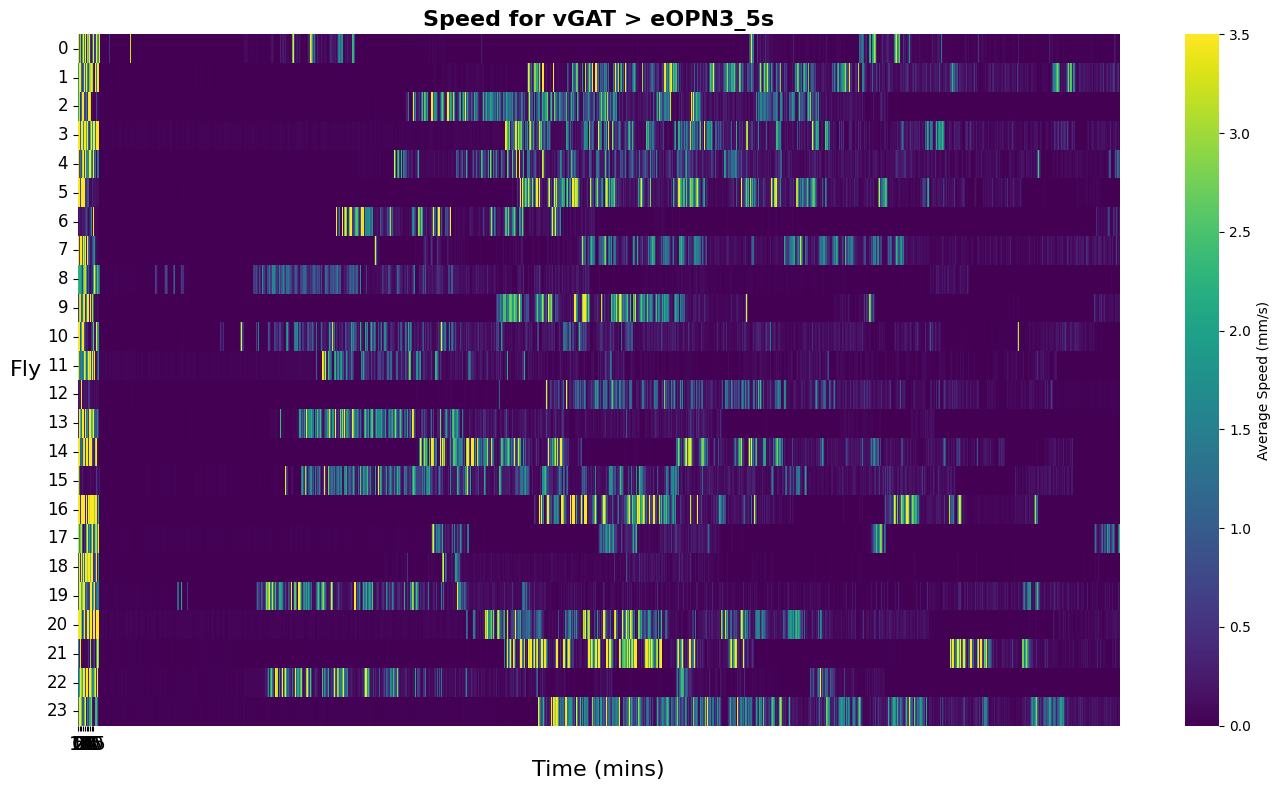

In [7]:
speeddf = intendedtimeexp.filter(regex="^Speed").T.reset_index(drop=True)

if responder == "eOPN3":
    responderrename = "AsOPN3"
if responder == "ACR":
    responderrename = "GtACR1"

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(speeddf, cmap="viridis", cbar_kws={'label': 'Average Speed (mm/s)'}, xticklabels=12, 
            yticklabels=True, vmin=0, vmax=3.5, ax=ax)

# Get the QuadMesh and force it to rasterize
quadmesh = ax.collections[0]
quadmesh.set_rasterized(True)
quadmesh.set_edgecolor('face')
quadmesh.set_linewidth(0)

ax.tick_params(axis='y', labelsize=12)

# Add illumination lines
# illum_start_idx = int(illum_start // bin_size)
# illum_end_idx = int((illum_start + illum_duration) // bin_size)
# ax.axvline(x=illum_start_idx, color='white', linewidth=2, linestyle='--', alpha=1.0)
# ax.axvline(x=illum_end_idx, color='white', linewidth=2, linestyle='--', alpha=1.0)

tick_times = range(0, int(intendedtime/60), int(intendedtime/600))
tick_positions = [list(speeddf.columns).index(float(t)) for t in tick_times if float(t) in speeddf.columns]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_times, rotation=0, fontsize=14)
ax.tick_params(axis='y', rotation=0)

ax.set_xlabel("Time (mins)", fontsize=16)
ax.set_ylabel("Fly", rotation=0, labelpad=15, fontsize=16)
ax.set_title("Speed for " + fileofinterestname.replace("x", ">"), weight="bold", fontsize=16)

fig.tight_layout()

import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'

fig.patch.set_facecolor('white')
ax.patch.set_facecolor('white')

# plt.savefig(homecomp + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data compilation\\Trumelan\\Trumelan images\\" 
#             + "Speed_" + respondercontrol_name + ".svg",
#             dpi=300, bbox_inches='tight', format='svg', facecolor='white', transparent=False)

In [ ]:
speeddf = intendedtimeexp.filter(regex="^Speed").T.reset_index(drop=True)

if responder == "eOPN3":
    responderrename = "AsOPN3"
if responder == "ACR":
    responderrename = "GtACR1"

plt.figure(figsize=(14, 8))
ax = sns.heatmap(speeddf, cmap="viridis", cbar_kws={'label': 'Average Speed (mm/s)'}, xticklabels=12, yticklabels=True, vmin=0, vmax=3.5)
plt.yticks(fontsize=12)

# Add illumination lines
illum_start_idx = int(illum_start // bin_size)
illum_end_idx = int((illum_start + illum_duration) // bin_size)
plt.axvline(x=illum_start_idx, color='white', linewidth=2, linestyle='--', alpha=1.0)
plt.axvline(x=illum_end_idx, color='white', linewidth=2, linestyle='--', alpha=1.0)

tick_times = range(0, 600, 60)  # 0, 30, 60, 90, ...
tick_positions = [list(activityleveldf.columns).index(float(t)) for t in tick_times if float(t) in activityleveldf.columns]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_times, rotation = 0, fontsize = 14)
plt.yticks(rotation=0)

plt.xlabel("Time (seconds)", fontsize = 16)
plt.ylabel("Fly",rotation =0, labelpad=15, fontsize = 16)
plt.title("Average Speed (mm/s) for " + driver + " > " + responderrename)
plt.tight_layout()


Time filter '5s' applied: 24 files found


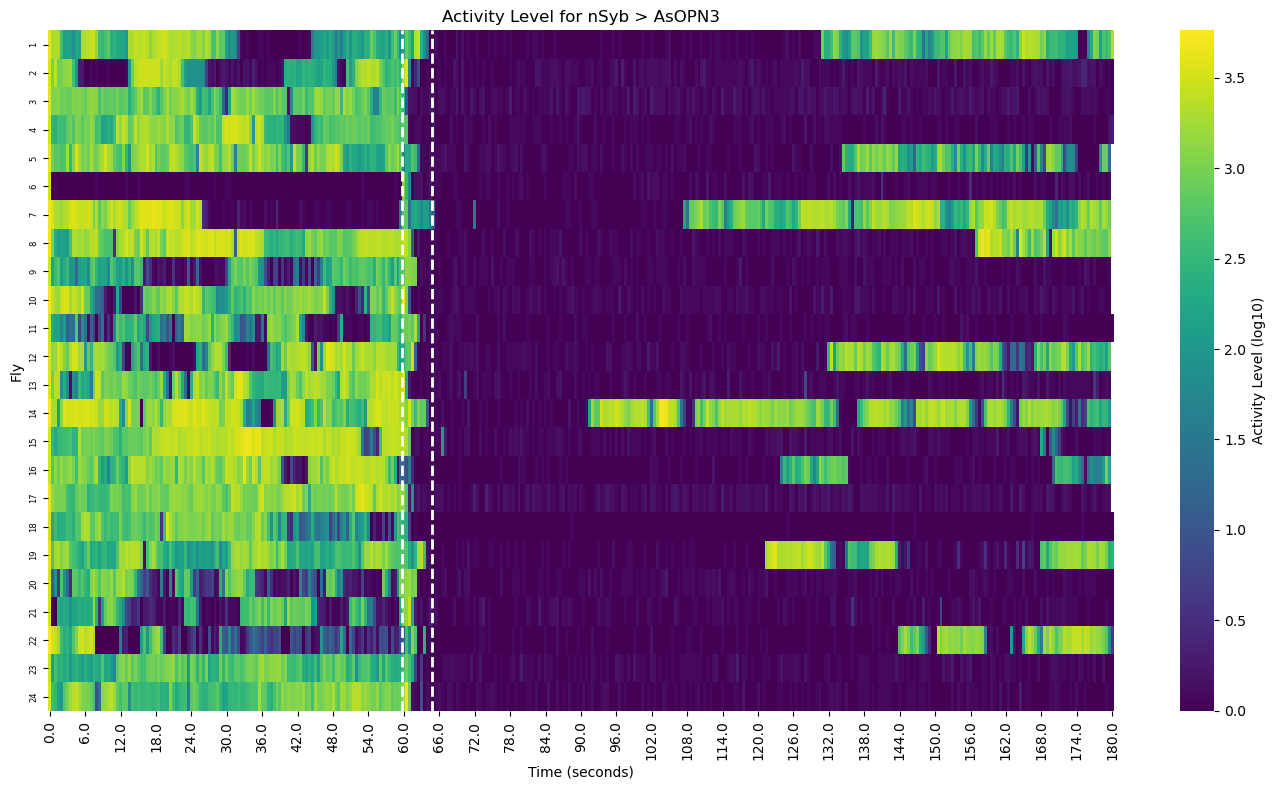

Time filter '5s' applied: 22 files found


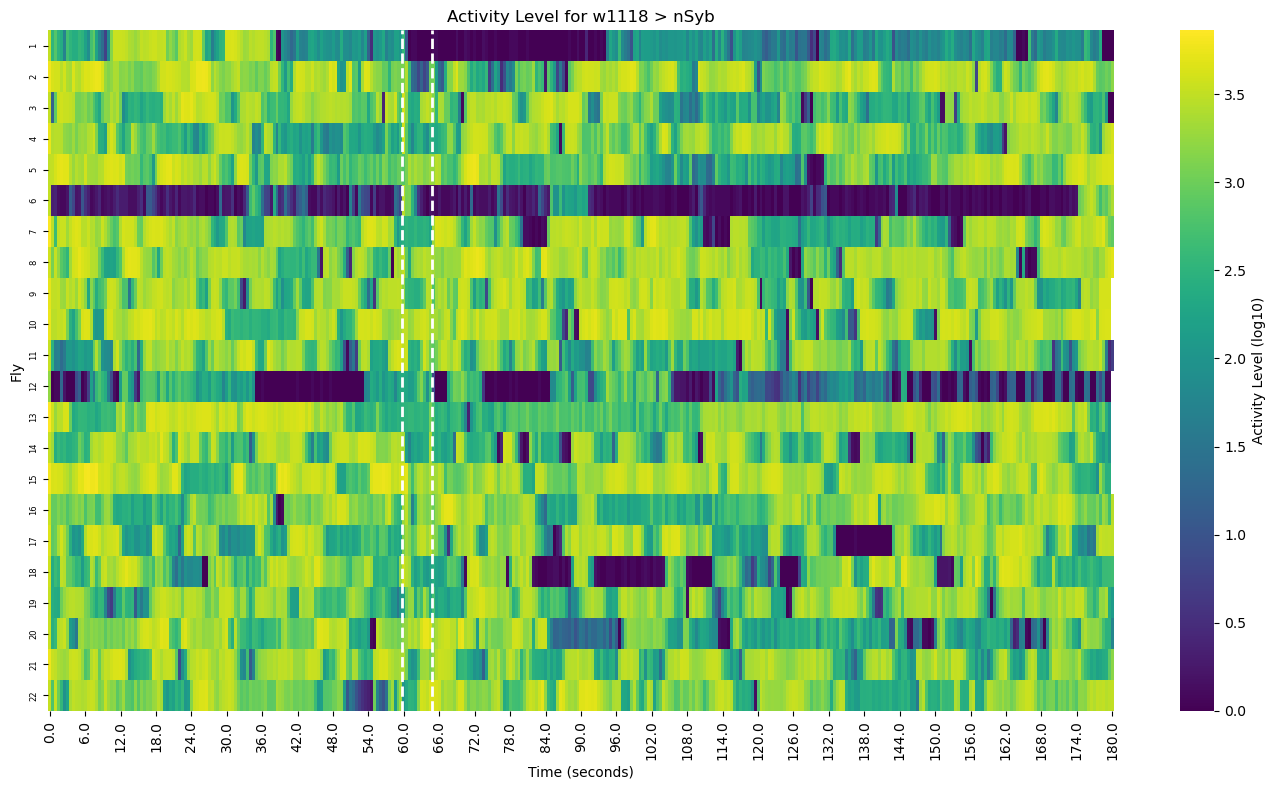

Time filter '5s' applied: 24 files found


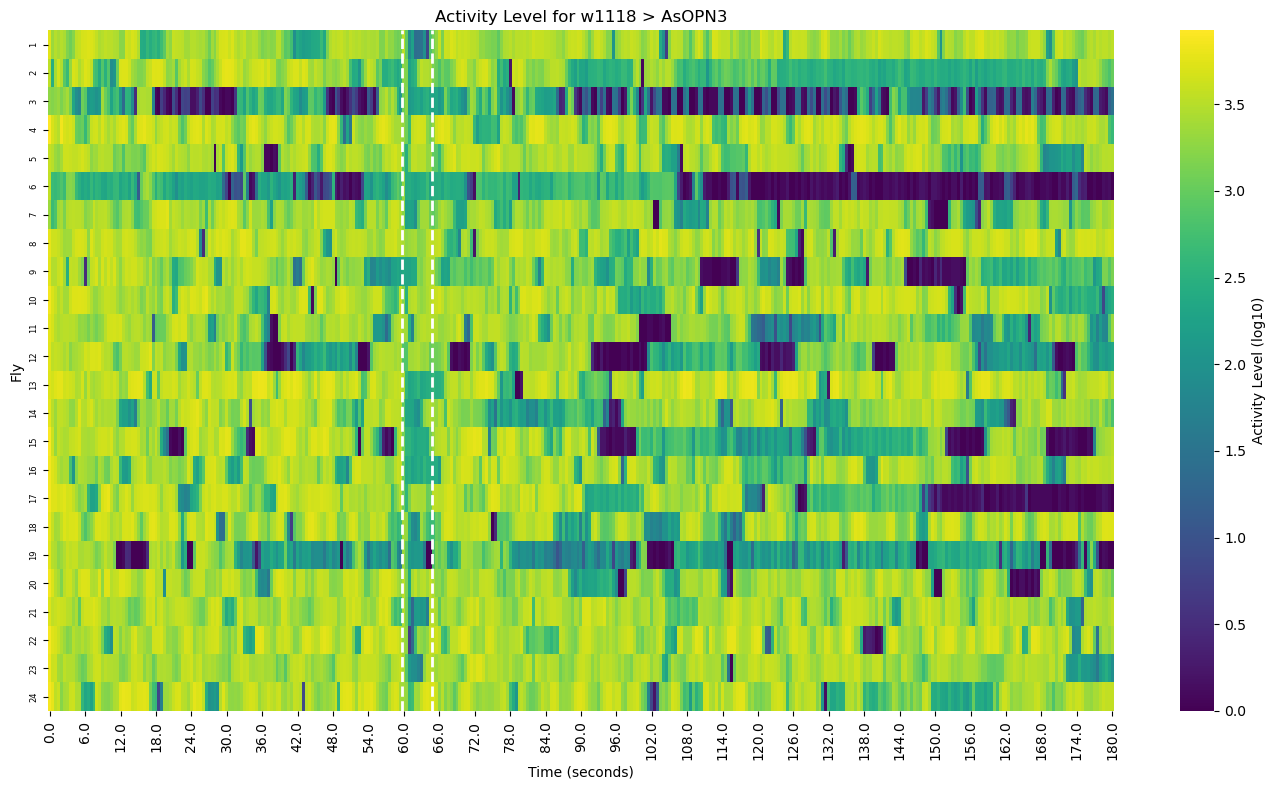

Time filter '5s' applied: 24 files found


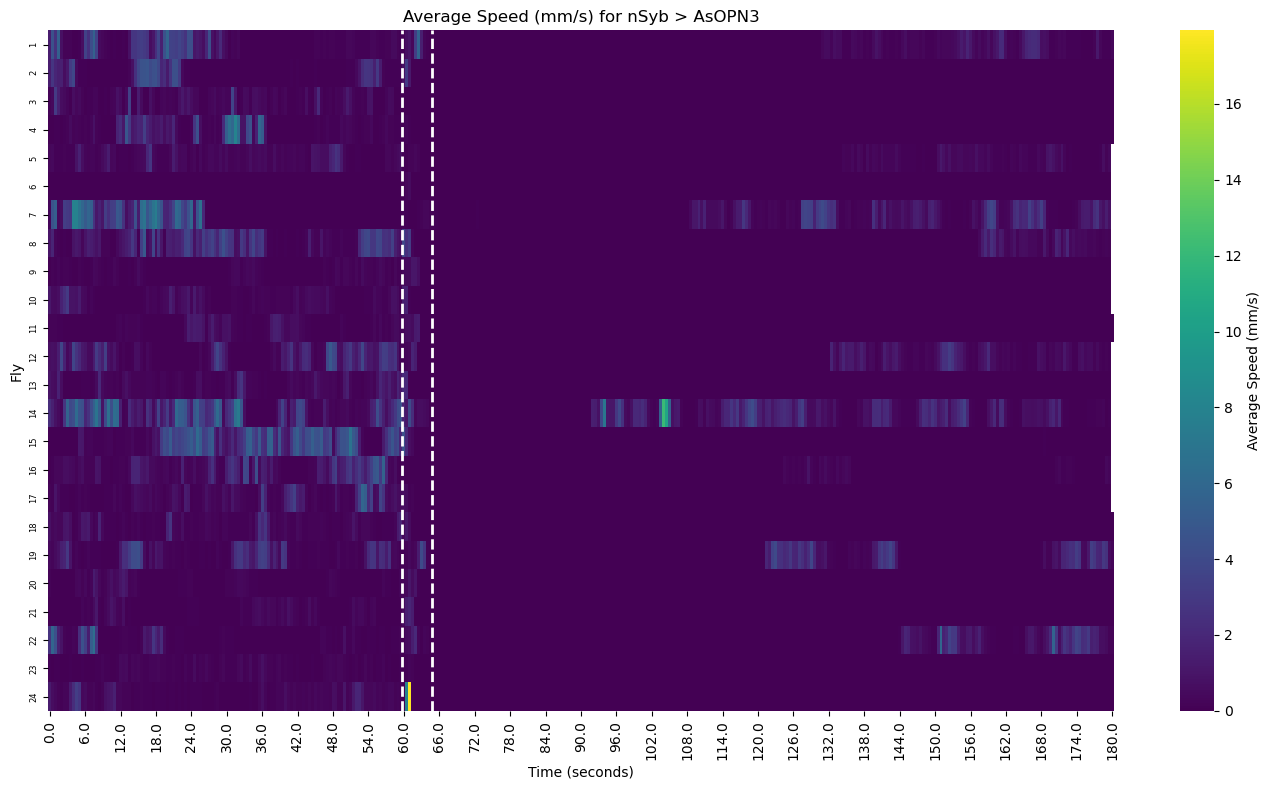

Time filter '5s' applied: 22 files found


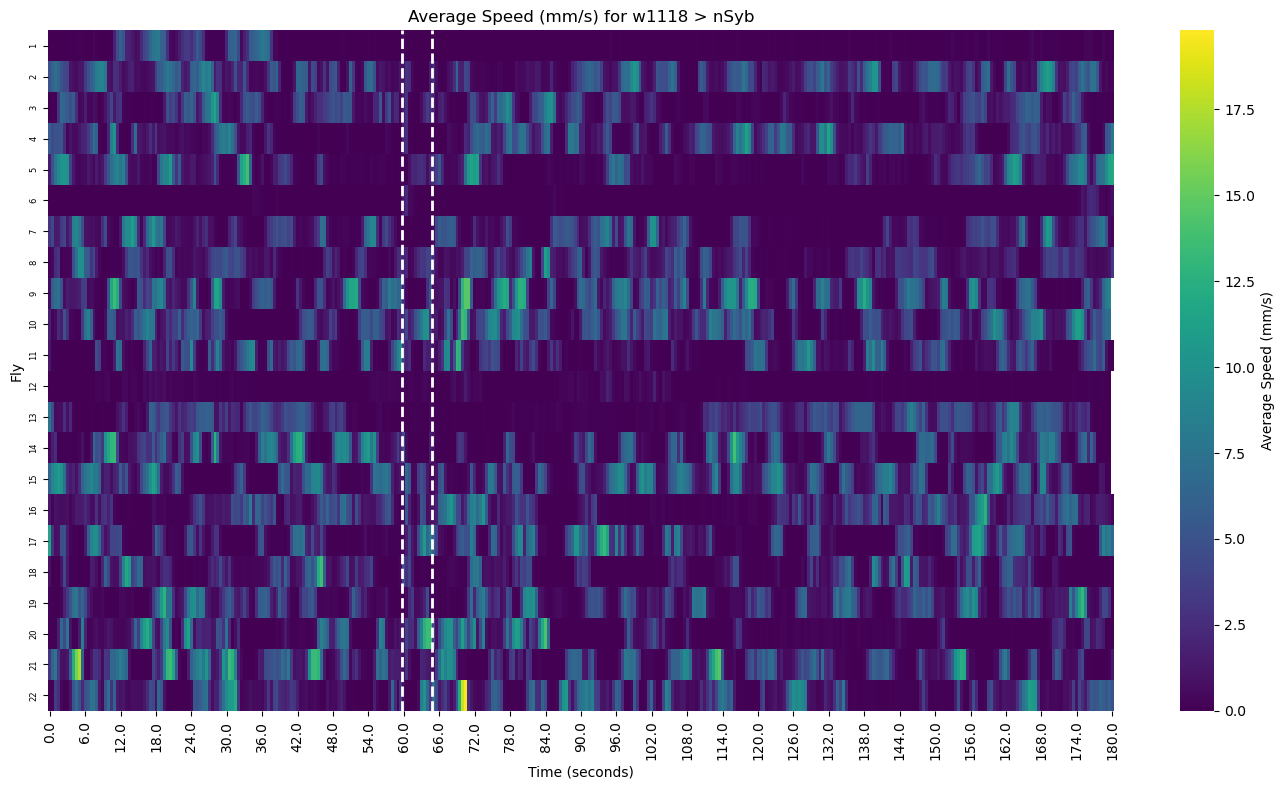

Time filter '5s' applied: 24 files found


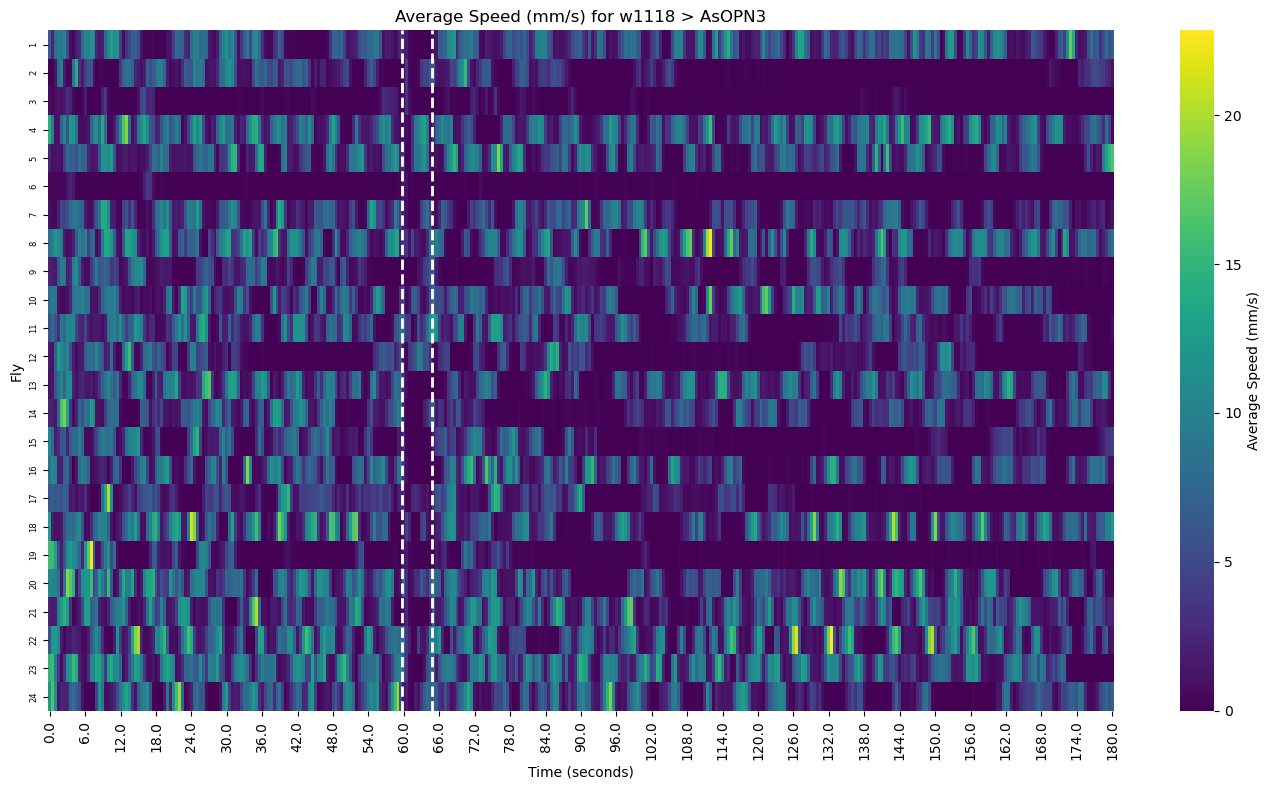

In [39]:
metrics = ["Activity Level", "Speed_Av_mm_per_sec"]
metric_labels = ["Activity Level", "Average Speed (mm/s)"]

# Check if folders exist
folders_exist = {
    "experimental": os.path.exists(exp_path),
    "control1": os.path.exists(control1_path),
    "control2": os.path.exists(control2_path)
}


for metric, metric_label in zip(metrics, metric_labels):
    
    # Load experimental data with time filter
    if folders_exist["experimental"]:
        exp_data = load_csv_data(exp_path, metric, time_filter=time)
        if exp_data is not None:
            fig = create_heatmap(
                exp_data, 
                f"{metric_label} for {transgenicnaming}",
                log_transform=(metric == "Activity Level")
            )
            
            # Save heatmap (uncomment if output_dir is defined)
            # filename = f"{genotypefilename}_{metric.replace(' ', '_').lower()}_heatmap.svg"
            # fig.savefig(os.path.join(output_dir, filename))
            plt.show()
        else:
            print(f"No data found in {exp_path}")
    else:
        print(f"Experimental folder not found: {exp_path}")
    
    # Load and display control data
    if folders_exist["control1"]:
        control1_data = load_csv_data(control1_path, metric, time_filter=time if 'time' in locals() else None)
        if control1_data is not None:
            fig = create_heatmap(
                control1_data, 
                f"{metric_label} for w1118 > {driver}",
                log_transform=(metric == "Activity Level")
            )
            
            # Save heatmap (uncomment if output_dir is defined)
            # filename = f"w1118_{driver}_{metric.replace(' ', '_').lower()}_heatmap.svg"
            # fig.savefig(os.path.join(output_dir, filename))
            plt.show()
    
    if folders_exist["control2"]:
        control2_data = load_csv_data(control2_path, metric, time_filter=time if 'time' in locals() else None)
        if control2_data is not None:
            fig = create_heatmap(
                control2_data, 
                f"{metric_label} for w1118 > {responderrename}",
                log_transform=(metric == "Activity Level")
            )
            
            # Save heatmap (uncomment if output_dir is defined)
            # filename = f"w1118_{responder}_{metric.replace(' ', '_').lower()}_heatmap.svg"
            # fig.savefig(os.path.join(output_dir, filename))
            plt.show()

## Linegraphs

In [ ]:
# Generate Linegraphs
# ===================

for metric, metric_label in zip(metrics, metric_labels):
    print(f"\n{'='*50}")
    print(f"Generating {metric_label} Linegraphs")
    print(f"{'='*50}")
    
    # Prepare data dictionary
    data_dict = {}
    
    # Load experimental data with time filter
    if folders_exist["experimental"]:
        exp_data = load_csv_data(exp_path, metric, time_filter=time if 'time' in locals() else None)
        if exp_data is not None:
            data_dict[transgenicnaming] = exp_data
    
    # Load control data with time filter
    if folders_exist["control1"]:
        control1_data = load_csv_data(control1_path, metric, time_filter=time if 'time' in locals() else None)
        if control1_data is not None:
            data_dict[f"w1118 > {driver}"] = control1_data
    
    if folders_exist["control2"]:
        control2_data = load_csv_data(control2_path, metric, time_filter=time if 'time' in locals() else None)
        if control2_data is not None:
            data_dict[f"w1118 > {responderrename}"] = control2_data
    
    # Create linegraph if we have data
    if data_dict:
        title_parts = list(data_dict.keys())
        if len(title_parts) > 1:
            title = f"{metric_label} for {title_parts[0]} vs. {' vs. '.join(title_parts[1:])}"
        else:
            title = f"{metric_label} for {title_parts[0]}"
            
        fig = create_linegraph(data_dict, title)
        
        # Save linegraph (uncomment if output_dir is defined)
        # filename = f"{genotypefilename}_{metric.replace(' ', '_').lower()}_linegraph.svg"
        # fig.savefig(os.path.join(output_dir, filename))
        plt.show()
    else:
        print(f"No data available for {metric_label} linegraph")

print(f"\n{'='*50}")
print("Analysis Complete!")
# print(f"Figures saved to: {output_dir}")
print(f"{'='*50}")